In [1]:
import sys
from pathlib import Path


def _find_project_root(start: Path) -> Path:
    for p in [start, *start.parents]:
        if (p / 'utility.py').exists():
            return p
    return start


PROJECT_ROOT = _find_project_root(Path.cwd())
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

DATA_DIR = PROJECT_ROOT / 'data'


##### Import libary

In [2]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.stats import fisher_exact, linregress, mannwhitneyu, spearmanr
from sklearn.metrics import confusion_matrix

import fcgr
import importlib
import kaos
import r_plot_utils
import utility

warnings.filterwarnings('ignore', category=pd.errors.PerformanceWarning)
pd.set_option('mode.chained_assignment', None)


In [3]:
kmer_length = 10
fasta_file_path = str(DATA_DIR / 'GCF_000017985.1_ASM1798v1_genomic.fna')


In [4]:
def strip_whitespace_from_string_columns(input_df):
    """
    Returns a copy of the DataFrame with leading and trailing whitespace removed
    from all string/object columns.
    
    Args:
        input_df (pd.DataFrame): Input DataFrame to process.
    
    Returns:
        pd.DataFrame: Copy with whitespace stripped from all string columns.
    """
    cleaned_df = input_df.copy()
    for column in cleaned_df.select_dtypes(include=['object', 'string']):
        cleaned_df[column] = cleaned_df[column].str.strip()
    return cleaned_df

In [5]:
# LTEE_mutational_data

In [6]:
mutational_data_all_population = pd.read_csv(DATA_DIR / 'LTEE_mutational_data.csv')
mutational_data_all_population = strip_whitespace_from_string_columns(mutational_data_all_population)


In [7]:
class Oligo:
    @staticmethod
    def kgain(mutational_data: pd.DataFrame, fasta_file_path: str, fasta_string: str, kmer_length: int, ref_fasta_string: str = None) -> pd.DataFrame:
        """
        Compute k-mer log-gain for mutations using frequency dictionary from a genome FASTA.

        Args:
            mutational_data (pd.DataFrame): DataFrame with '#CHROM', 'POS', 'REF', 'ALT' columns.
            fasta_file_path (str): Path to the reference genome FASTA file.
            fasta_string (str): Genome string used to build the FCGR dictionary (may be evolved).
            kmer_length (int): Length of k-mers to use (e.g., 10).
            ref_fasta_string (str, optional): Pre-loaded reference genome string for flank fetching.
                If None, loaded from fasta_file_path. Pass this to avoid redundant file reads.

        Returns:
            pd.DataFrame: Result table with mutation context and kGain.
        """
        import numpy as np
        import pandas as pd
        import kaos

        mutational_data = mutational_data.copy()
        mutational_data.reset_index(inplace=True, drop=True)
        required_cols = ['#CHROM', 'POS', 'REF', 'ALT']
        missing = [col for col in required_cols if col not in mutational_data.columns]
        if missing:
            raise ValueError(
                f"Input DataFrame is missing required column(s): {', '.join(missing)}.\n"
                f"Columns found: {list(mutational_data.columns)}"
            )
        n_duplicates = mutational_data.duplicated(subset=required_cols).sum()
        if n_duplicates > 0:
            print(f"[Warning] Found {n_duplicates} duplicate mutation(s) in input DataFrame (by {required_cols}). Duplicates will be dropped.")
            mutational_data = mutational_data.drop_duplicates(subset=required_cols).reset_index(drop=True)

        flank_size = kmer_length - 1

        # fasta_string (evolved or WT genome) is used only for the FCGR frequency dictionary.
        fcgr_dict = kaos.chaos_frequency_dictionary(
            fasta_string=fasta_string,
            kmer_length=kmer_length,
            pseudo_count=True,
            chaos_game_kmer_array=kaos.chaos_game_representation_key(kmer_length=kmer_length)
        )
        # Flanks are always taken from the reference genome so that already-fixed mutations
        # are not silently dropped by the ref-allele mismatch check.
        if ref_fasta_string is None:
            ref_fasta_string = kaos.read_fasta(fasta_file_path)

        for col in mutational_data.select_dtypes(include=['object', 'string']):
            mutational_data[col] = mutational_data[col].str.strip()

        kmer_windows_result = []

        for i in range(mutational_data.shape[0]):
            try:
                chrom_id = mutational_data.loc[i, "#CHROM"]
                genome_pos = int(mutational_data.loc[i, "POS"])
                ref_allele = mutational_data.loc[i, "REF"]
                alt_allele = mutational_data.loc[i, "ALT"]

                assert isinstance(ref_allele, str) and len(ref_allele) == 1, f"Reference allele not a single base at row {i}"
                assert isinstance(alt_allele, str) and len(alt_allele) == 1, f"Alternate allele not a single base at row {i}"

                start_idx = genome_pos - flank_size - 1
                end_idx = genome_pos + flank_size
                if start_idx < 0 or end_idx > len(ref_fasta_string):
                    print(f"[Warning] Skipping row {i} due to out-of-bound flank range (CHROM={chrom_id}, POS={genome_pos}).")
                    continue
                ref_flank_seq = ref_fasta_string[start_idx:end_idx]

                center_idx = kmer_length - 1
                if ref_flank_seq[center_idx] != ref_allele:
                    print(f"[Warning] Reference allele mismatch at row {i}: {ref_flank_seq[center_idx]} != {ref_allele} (CHROM={chrom_id}, POS={genome_pos})")
                    continue

                mutated_flank_seq = (
                    ref_flank_seq[:center_idx] + alt_allele + ref_flank_seq[center_idx+1:]
                )

                expected_len = 2 * flank_size + 1
                if len(ref_flank_seq) != expected_len or len(mutated_flank_seq) != expected_len:
                    print(f"[Warning] Skipping row {i} due to flank length mismatch: len(ref_flank_seq)={len(ref_flank_seq)}, len(mutated_flank_seq)={len(mutated_flank_seq)}, expected={expected_len}")
                    continue

                for j in range(kmer_length):
                    alt_window = mutated_flank_seq[center_idx - kmer_length + j + 1 : center_idx + 1 + j]
                    ref_window = ref_flank_seq[center_idx - kmer_length + j + 1 : center_idx + j + 1]

                    if len(alt_window) != kmer_length or len(ref_window) != kmer_length:
                        continue

                    try:
                        ratio = fcgr_dict[alt_window] / fcgr_dict[ref_window]
                        window_gain = np.log(ratio)
                    except KeyError as e:
                        print(f"[Warning] Missing k-mer in FCGR at row {i}, window {j}: {e}")
                        continue
                    except Exception as e:
                        print(f"[Error] Unexpected error at row {i}, window {j}: {e}")
                        continue

                    row = {
                        '#CHROM': chrom_id,
                        'POS': genome_pos,
                        "REF": ref_allele,
                        "ALT": alt_allele,
                        'ref_flank_seq': ref_flank_seq,
                        'mutated_flank_seq': mutated_flank_seq,
                        'altered_sliding_window': alt_window,
                        'reference_sliding_window': ref_window,
                        'window_number': j,
                        'window_gain': window_gain,
                    }
                    kmer_windows_result.append(row)

            except AssertionError as e:
                print(f"[Assertion Error] Row {i}: {e}")
            except Exception as e:
                print(f"[Exception] Row {i}: {e}")

        df_kmer_windows = pd.DataFrame(kmer_windows_result)

        mutation_kmer_gain_df = (
            df_kmer_windows
            .groupby(['#CHROM','POS', "REF", "ALT", 'ref_flank_seq', 'mutated_flank_seq'])["window_gain"]
            .sum()
            .reset_index()
            .rename(columns={"window_gain": "kGain"})
        )

        return mutation_kmer_gain_df


    @staticmethod
    def window_wise_kgain(mutational_data: pd.DataFrame, fasta_string: str, fasta_file_path: str, kmer_length: int, ref_fasta_string: str = None) -> pd.DataFrame:
        """
        Compute k-mer log-gain for mutations using frequency dictionary from a genome FASTA.

        Args:
            mutational_data (pd.DataFrame): DataFrame with '#CHROM', 'POS', 'REF', 'ALT' columns.
            fasta_file_path (str): Path to the reference genome FASTA file.
            fasta_string (str): Genome string used to build the FCGR dictionary (may be evolved).
            kmer_length (int): Length of k-mers to use (e.g., 10).
            ref_fasta_string (str, optional): Pre-loaded reference genome string for flank fetching.
                If None, loaded from fasta_file_path. Pass this to avoid redundant file reads.

        Returns:
            pd.DataFrame: Result table with mutation context and window wise kGain.
        """
        import numpy as np
        import pandas as pd
        import kaos

        mutational_data = mutational_data.copy()
        mutational_data.reset_index(inplace=True, drop=True)
        required_cols = ['#CHROM', 'POS', 'REF', 'ALT']
        missing = [col for col in required_cols if col not in mutational_data.columns]
        if missing:
            raise ValueError(
                f"Input DataFrame is missing required column(s): {', '.join(missing)}.\n"
                f"Columns found: {list(mutational_data.columns)}"
            )
        n_duplicates = mutational_data.duplicated(subset=required_cols).sum()
        if n_duplicates > 0:
            print(f"[Warning] Found {n_duplicates} duplicate mutation(s) in input DataFrame (by {required_cols}). Duplicates will be dropped.")
            mutational_data = mutational_data.drop_duplicates(subset=required_cols).reset_index(drop=True)

        flank_size = kmer_length - 1
        fcgr_dict = kaos.chaos_frequency_dictionary(
            fasta_string=fasta_string,
            kmer_length=kmer_length,
            pseudo_count=True,
            chaos_game_kmer_array=kaos.chaos_game_representation_key(kmer_length=kmer_length)
        )
        if ref_fasta_string is None:
            ref_fasta_string = kaos.read_fasta(fasta_file_path)

        for col in mutational_data.select_dtypes(include=['object', 'string']):
            mutational_data[col] = mutational_data[col].str.strip()

        kmer_windows_result = []

        for i in range(mutational_data.shape[0]):
            try:
                chrom_id = mutational_data.loc[i, "#CHROM"]
                genome_pos = int(mutational_data.loc[i, "POS"])
                ref_allele = mutational_data.loc[i, "REF"]
                alt_allele = mutational_data.loc[i, "ALT"]

                assert isinstance(ref_allele, str) and len(ref_allele) == 1, f"Reference allele not a single base at row {i}"
                assert isinstance(alt_allele, str) and len(alt_allele) == 1, f"Alternate allele not a single base at row {i}"

                start_idx = genome_pos - flank_size - 1
                end_idx = genome_pos + flank_size
                if start_idx < 0 or end_idx > len(ref_fasta_string):
                    print(f"[Warning] Skipping row {i} due to out-of-bound flank range (CHROM={chrom_id}, POS={genome_pos}).")
                    continue
                ref_flank_seq = ref_fasta_string[start_idx:end_idx]

                center_idx = kmer_length - 1
                if ref_flank_seq[center_idx] != ref_allele:
                    print(f"[Warning] Reference allele mismatch at row {i}: {ref_flank_seq[center_idx]} != {ref_allele} (CHROM={chrom_id}, POS={genome_pos})")
                    continue

                mutated_flank_seq = (
                    ref_flank_seq[:center_idx] + alt_allele + ref_flank_seq[center_idx+1:]
                )

                expected_len = 2 * flank_size + 1
                if len(ref_flank_seq) != expected_len or len(mutated_flank_seq) != expected_len:
                    print(f"[Warning] Skipping row {i} due to flank length mismatch: len(ref_flank_seq)={len(ref_flank_seq)}, len(mutated_flank_seq)={len(mutated_flank_seq)}, expected={expected_len}")
                    continue

                for j in range(kmer_length):
                    alt_window = mutated_flank_seq[center_idx - kmer_length + j + 1 : center_idx + 1 + j]
                    ref_window = ref_flank_seq[center_idx - kmer_length + j + 1 : center_idx + j + 1]

                    if len(alt_window) != kmer_length or len(ref_window) != kmer_length:
                        continue

                    try:
                        ratio = fcgr_dict[alt_window] / fcgr_dict[ref_window]
                        window_gain = np.log(ratio)
                    except KeyError as e:
                        print(f"[Warning] Missing k-mer in FCGR at row {i}, window {j}: {e}")
                        continue
                    except Exception as e:
                        print(f"[Error] Unexpected error at row {i}, window {j}: {e}")
                        continue

                    row = {
                        "chromosome_id": chrom_id,
                        'genome_position': genome_pos,
                        'reference_allele': ref_allele,
                        'alternate_allele': alt_allele,
                        'ref_flank_seq': ref_flank_seq,
                        'mutated_flank_seq': mutated_flank_seq,
                        'altered_sliding_window': alt_window,
                        'reference_sliding_window': ref_window,
                        'window_number': j,
                        'window_gain': window_gain,
                    }
                    kmer_windows_result.append(row)

            except AssertionError as e:
                print(f"[Assertion Error] Row {i}: {e}")
            except Exception as e:
                print(f"[Exception] Row {i}: {e}")

        df_kmer_windows = pd.DataFrame(kmer_windows_result)

        return df_kmer_windows

In [8]:
allele_counts_by_generation = pd.read_excel(DATA_DIR / 'MetaData_ecoli_final.xlsx', sheet_name='Mastersheet')
allele_counts_by_generation.drop_duplicates(subset=['CHROM', 'Position', 'Gene', 'Allele', 'Annotation', 'Ref_allele', 'Alt_allele', 'label'], inplace=True)
allele_counts_by_generation.reset_index(inplace=True, drop=True)
allele_counts_by_generation.rename(columns={'CHROM': '#CHROM', 'Position': 'POS', 'Ref_allele': 'REF', 'Alt_allele': 'ALT', 'label': 'population_label'}, inplace=True)
allele_counts_by_generation['key'] = (
    allele_counts_by_generation['#CHROM'].astype(str) + '_' +
    allele_counts_by_generation['REF'] + '_' +
    allele_counts_by_generation['POS'].astype(str) + '_' +
    allele_counts_by_generation['ALT'] + '_' +
    allele_counts_by_generation['population_label'].astype(str)
)
allele_counts_by_generation = strip_whitespace_from_string_columns(allele_counts_by_generation)
allele_counts_by_generation.shape


(36922, 126)

In [9]:
allele_count_columns = [item for item in allele_counts_by_generation if item.startswith("AC")] ## Fiter the column starting with "AC" which indicate allele count
allele_count_columns.extend(['#CHROM','POS', 'Gene', 'Allele', 'Annotation', 'REF', 'ALT','population_label', 'key']) ##Add other relavent information
allele_counts_by_generation = allele_counts_by_generation[allele_count_columns]
print(allele_counts_by_generation.shape)

(36922, 126)


In [10]:
nan_columns = allele_counts_by_generation.columns[allele_counts_by_generation.isna().any()]
df_with_nan = allele_counts_by_generation[nan_columns]
nan_counts = allele_counts_by_generation.isna().sum()
nan_counts = nan_counts[nan_counts > 0]
print("\n Number of NaN values in each column:")
print(nan_counts)


 Number of NaN values in each column:
AC:2500      355
AC:15000    4953
AC:46500     331
AC:58000    3753
AC:58500     355
AC:59000     355
AC:59500     355
AC:60000     355
dtype: int64


In [11]:
allele_counts_by_generation.drop(nan_counts.index.tolist(), axis = 1, inplace=True)
allele_counts_by_generation.reset_index(inplace=True, drop = True)
allele_counts_by_generation.shape

(36922, 118)

In [12]:
ac_columns = [item for item in allele_counts_by_generation.columns if item.startswith('AC:')]

In [13]:
# Make a working copy of the input DataFrame
allele_counts_per_generation = allele_counts_by_generation.copy()

# This DataFrame will store all per-mutation, per-generation, per-population records
long_format_mutation_counts = pd.DataFrame()

for generation_col in ac_columns:
    # Filter mutations where the allele count for this generation is nonzero
    nonzero_mutations = allele_counts_per_generation[allele_counts_per_generation[generation_col] != 0]

    # Select all relevant mutation and annotation information
    mutation_data = nonzero_mutations[['#CHROM', 'POS', 'Gene', 'REF', 'ALT', "population_label", "Annotation"]].copy()
    mutation_data['generation_label'] = generation_col
    mutation_data['allele_count'] = nonzero_mutations[generation_col]
    # If population_label is already included, this line is redundant, otherwise uncomment:
    # mutation_data['population_label'] = population

    # Append the records for this generation to the long-format DataFrame
    long_format_mutation_counts = pd.concat([long_format_mutation_counts, mutation_data], axis=0)

# Reset index after concatenation
long_format_mutation_counts.reset_index(inplace=True, drop=True)

# Extract the numeric generation (e.g., 'AC:1000' -> 1000)
long_format_mutation_counts['generation_number'] = (
    long_format_mutation_counts['generation_label'].str.extract(r'(\d+)').astype(int)
)
long_format_mutation_counts.drop("generation_label", axis=1, inplace=True)
long_format_mutation_counts.reset_index(inplace=True, drop=True)

long_format_mutation_counts['key'] = (
    long_format_mutation_counts['#CHROM'].astype(str) + '_' +
    long_format_mutation_counts['REF'] + '_' +
    long_format_mutation_counts['POS'].astype(str) + '_' +
    long_format_mutation_counts['ALT'] + '_' +
    long_format_mutation_counts['population_label'].astype(str) + '_' +
    long_format_mutation_counts['generation_number'].astype(str)
)



In [14]:
def mutate_fasta_by_generation(
    variant_data: pd.DataFrame,
    fasta_file_path: str,
    target_generation: int
) -> str:
    """
    Returns a mutated FASTA sequence for a specific generation, 
    substituting alternate alleles at given positions.

    Args:
        variant_data (pd.DataFrame): DataFrame with columns 
            ['#CHROM', 'POS', 'REF', 'ALT', 'generation_number'].
        fasta_file_path (str): Path to the reference genome FASTA file.
        target_generation (int): The generation number to apply mutations for.

    Returns:
        str: Mutated DNA sequence as a string.

    Raises:
        ValueError: If required columns are missing.
    """
    import kaos

    required_cols = ['#CHROM', 'POS', 'REF', 'ALT', 'generation_number']
    missing_cols = [col for col in required_cols if col not in variant_data.columns]
    if missing_cols:
        raise ValueError(
            f"Input DataFrame is missing required columns: {', '.join(missing_cols)}.\n"
            f"Columns found: {list(variant_data.columns)}"
        )

    variant_data = variant_data.copy()

    # Warn if duplicates are dropped
    before = variant_data.shape[0]
    variant_data = variant_data.drop_duplicates(subset=required_cols)
    after = variant_data.shape[0]
    if after < before:
        variant_data.drop_duplicates(inplace=True)
        variant_data.reset_index(inplace=True, drop=True)
        print(f"[Warning] Dropped {before - after} duplicate variant(s) based on columns {required_cols}.")

    # Read the reference sequence from FASTA
    reference_seq = kaos.read_fasta(fasta_file_path)

    # Filter mutations for the target generation
    relevant_variants = variant_data[variant_data["generation_number"] == target_generation]

    mutated_seq = list(reference_seq)
    for pos, alt_allele in zip(relevant_variants["POS"].astype(int), relevant_variants["ALT"]):
        seq_index = pos - 1  # 1-based to 0-based
        if 0 <= seq_index < len(mutated_seq):
            mutated_seq[seq_index] = alt_allele

    return ''.join(mutated_seq)


In [15]:
ref_fasta_string = kaos.read_fasta(fasta_file_path)

In [16]:
kgain_all_population_evolved = pd.DataFrame()

target_generation = 57500

dct_fasta_pop_wise_target_generation_57500 = dict()
for population in set(long_format_mutation_counts["population_label"]):

    individual_population_wise_mutation_counts, individual_population_wise_mutation_counts_for_selected_generation = [None] * 2

    individual_population_wise_mutation_counts = long_format_mutation_counts[long_format_mutation_counts["population_label"]==population]
    individual_population_wise_mutation_counts_for_selected_generation = individual_population_wise_mutation_counts[individual_population_wise_mutation_counts["generation_number"]==target_generation]
    individual_population_wise_mutation_counts_for_selected_generation.reset_index(inplace=True, drop=True)
    dct_fasta_pop_wise_target_generation_57500[population] = mutate_fasta_by_generation(variant_data = individual_population_wise_mutation_counts_for_selected_generation, fasta_file_path = fasta_file_path, target_generation=target_generation)
    

for population in set(mutational_data_all_population["population_label"]):
    pop_wise_mutational_data, kgain_individual_population, fasta_individual_population, fasta_string = [None] * 4
    fasta_individual_population = fasta_file_path
    fasta_string = dct_fasta_pop_wise_target_generation_57500[population]
    pop_wise_mutational_data = mutational_data_all_population[mutational_data_all_population["population_label"]==population][['#CHROM', 'POS', 'REF', 'ALT']]
    kgain_individual_population = Oligo.kgain(mutational_data=pop_wise_mutational_data, fasta_string=fasta_string, fasta_file_path=fasta_file_path, kmer_length=kmer_length, ref_fasta_string=ref_fasta_string)
    kgain_individual_population["population_label"] = population
    kgain_all_population_evolved = pd.concat([kgain_all_population_evolved, kgain_individual_population])
kgain_all_population_evolved.reset_index(inplace=True, drop=True)
kgain_all_population_evolved.rename(columns={"kGain": "evolved_kGain"}, inplace=True)

In [17]:
kgain_all_population_evolved['key'] = (
    kgain_all_population_evolved['#CHROM'].astype(str) + '_' +
    kgain_all_population_evolved['REF'] + '_' +
    kgain_all_population_evolved['POS'].astype(str) + '_' +
    kgain_all_population_evolved['ALT'] + '_' +
    kgain_all_population_evolved['population_label'].astype(str)
)

In [18]:
kgain_all_population_evolved.shape

(36922, 9)

In [19]:
kgain_all_population_evolved.head()

,#CHROM,POS,REF,ALT,ref_flank_seq,mutated_flank_seq,evolved_kGain,population_label,key
0,NC_012967.1,63,A,C,GAGTGTCTGATAGCAGCTT,GAGTGTCTGCTAGCAGCTT,-1.937942,p6,NC_012967.1_A_63_C_p6
1,NC_012967.1,201,T,G,GAAACGCATTAGCACCACC,GAAACGCATGAGCACCACC,1.157555,p6,NC_012967.1_T_201_G_p6
2,NC_012967.1,322,A,G,CCAAAGGTAACGAGGTAAC,CCAAAGGTAGCGAGGTAAC,0.616186,p6,NC_012967.1_A_322_G_p6
3,NC_012967.1,1173,T,G,CAGATCCCTTGCCTGATTA,CAGATCCCTGGCCTGATTA,2.932760,p6,NC_012967.1_T_1173_G_p6
4,NC_012967.1,1624,T,C,TTGTCGCCATTGCTCAGGG,TTGTCGCCACTGCTCAGGG,-5.511868,p6,NC_012967.1_T_1624_C_p6


In [20]:
kgain_all_population_wt = pd.DataFrame()

for population in set(mutational_data_all_population["population_label"]):
    pop_wise_mutational_data, kgain_individual_population, fasta_individual_population, fasta_string = [None] * 4
    fasta_individual_population = fasta_file_path
    fasta_string = ref_fasta_string  # WT: FCGR built from reference genome
    pop_wise_mutational_data = mutational_data_all_population[mutational_data_all_population["population_label"]==population][['#CHROM', 'POS', 'REF', 'ALT']]
    kgain_individual_population = Oligo.kgain(mutational_data=pop_wise_mutational_data, fasta_string=fasta_string, fasta_file_path=fasta_file_path, kmer_length=kmer_length, ref_fasta_string=ref_fasta_string)
    kgain_individual_population["population_label"] = population
    kgain_all_population_wt = pd.concat([kgain_all_population_wt, kgain_individual_population])

kgain_all_population_wt.reset_index(inplace=True, drop=True)
kgain_all_population_wt.rename(columns={"kGain": "wild_type_kGain"}, inplace=True)

In [21]:
kgain_all_population_wt.head()

,#CHROM,POS,REF,ALT,ref_flank_seq,mutated_flank_seq,wild_type_kGain,population_label
0,NC_012967.1,63,A,C,GAGTGTCTGATAGCAGCTT,GAGTGTCTGCTAGCAGCTT,-10.385914,p6
1,NC_012967.1,201,T,G,GAAACGCATTAGCACCACC,GAAACGCATGAGCACCACC,-1.750693,p6
2,NC_012967.1,322,A,G,CCAAAGGTAACGAGGTAAC,CCAAAGGTAGCGAGGTAAC,1.532477,p6
3,NC_012967.1,1173,T,G,CAGATCCCTTGCCTGATTA,CAGATCCCTGGCCTGATTA,-1.685811,p6
4,NC_012967.1,1624,T,C,TTGTCGCCATTGCTCAGGG,TTGTCGCCACTGCTCAGGG,-5.939527,p6


In [22]:
mutator_list = ['m1', 'm2', 'm3', 'm4', 'p3', 'p6']
non_mutator_list = ['p1', 'p2', 'p4', 'p5', 'm5', 'm6']

In [23]:
def classify_mutator_type(pop_label):
    if pop_label in mutator_list:
        return "mutator"
    elif pop_label in non_mutator_list:
        return "non_mutator"
    else:
        return np.nan  # or "other" if you want a default
    
long_format_mutation_counts["mutator_type"] = long_format_mutation_counts["population_label"].apply(classify_mutator_type)
long_format_mutation_counts.head()

,#CHROM,POS,Gene,REF,ALT,population_label,Annotation,allele_count,generation_number,key,mutator_type
0,chrI,73002,intergenic,C,T,p1,noncoding,2,0,chrI_C_73002_T_p1_0,non_mutator
1,chrI,144449,hpt,C,T,p1,synonymous,1,0,chrI_C_144449_T_p1_0,non_mutator
2,chrI,458736,kefA,C,T,p1,missense,1,0,chrI_C_458736_T_p1_0,non_mutator
3,chrI,524856,purE,G,A,p1,missense,1,0,chrI_G_524856_A_p1_0,non_mutator
4,chrI,557008,ECB_00513,C,T,p1,missense,2,0,chrI_C_557008_T_p1_0,non_mutator


In [24]:
kgain_all_population_wt["#CHROM"]  = "chrI"
kgain_all_population_evolved["#CHROM"]  = "chrI"

In [25]:
# create new key col with some cols
kgain_all_population_evolved['unique_mutation_key'] = (
    kgain_all_population_evolved['#CHROM'].astype(str) + '_' +
    
    kgain_all_population_evolved['REF'] + '_' +
    kgain_all_population_evolved['POS'].astype(str) + '_' +
    kgain_all_population_evolved['ALT'] + '_' +
    kgain_all_population_evolved['population_label'].astype(str)
)

kgain_all_population_wt['unique_mutation_key'] = (
    kgain_all_population_wt['#CHROM'].astype(str) + '_' +
    kgain_all_population_wt['REF'] + '_' +
    kgain_all_population_wt['POS'].astype(str) + '_' +
    kgain_all_population_wt['ALT'] + '_' +
    kgain_all_population_wt['population_label'].astype(str)
    # long_format_mutation_counts['generation_number'].astype(str)
)

In [26]:
kgain_all_population_wt =strip_whitespace_from_string_columns(kgain_all_population_wt)
long_format_mutation_counts =strip_whitespace_from_string_columns(long_format_mutation_counts)
kgain_all_population_evolved =strip_whitespace_from_string_columns(kgain_all_population_evolved)


In [27]:
kgain_all_population_wt

,#CHROM,POS,REF,ALT,ref_flank_seq,mutated_flank_seq,wild_type_kGain,population_label,unique_mutation_key
0,chrI,63,A,C,GAGTGTCTGATAGCAGCTT,GAGTGTCTGCTAGCAGCTT,-10.385914,p6,chrI_A_63_C_p6
1,chrI,201,T,G,GAAACGCATTAGCACCACC,GAAACGCATGAGCACCACC,-1.750693,p6,chrI_T_201_G_p6
2,chrI,322,A,G,CCAAAGGTAACGAGGTAAC,CCAAAGGTAGCGAGGTAAC,1.532477,p6,chrI_A_322_G_p6
3,chrI,1173,T,G,CAGATCCCTTGCCTGATTA,CAGATCCCTGGCCTGATTA,-1.685811,p6,chrI_T_1173_G_p6
4,chrI,1624,T,C,TTGTCGCCATTGCTCAGGG,TTGTCGCCACTGCTCAGGG,-5.939527,p6,chrI_T_1624_C_p6
...,...,...,...,...,...,...,...,...,...
36917,chrI,4627189,G,A,AGTGACGACGCCAGCCGAT,AGTGACGACACCAGCCGAT,-11.904011,m4,chrI_G_4627189_A_m4
36918,chrI,4627230,A,G,CGACTAAGTACGCCATTCT,CGACTAAGTGCGCCATTCT,-5.891219,m4,chrI_A_4627230_G_m4
36919,chrI,4627852,G,C,AATACGGCGGATCGTCACG,AATACGGCGCATCGTCACG,2.933801,m4,chrI_G_4627852_C_m4
36920,chrI,4628507,A,G,ACAGGAAGTACAAAAGTCC,ACAGGAAGTGCAAAAGTCC,-0.770108,m4,chrI_A_4628507_G_m4


In [28]:
merge_keys_mut = [
    "#CHROM", "POS", "REF", "ALT", "population_label"
]

merged_mutation_metrics_wt = pd.merge(
    long_format_mutation_counts,
    kgain_all_population_wt,
    on=merge_keys_mut,
    how="left"
)
merged_mutation_metrics_wt = strip_whitespace_from_string_columns(merged_mutation_metrics_wt)
merged_mutation_metrics_wt.head()


,#CHROM,POS,Gene,REF,ALT,population_label,Annotation,allele_count,generation_number,key,mutator_type,ref_flank_seq,mutated_flank_seq,wild_type_kGain,unique_mutation_key
0,chrI,73002,intergenic,C,T,p1,noncoding,2,0,chrI_C_73002_T_p1_0,non_mutator,ACTTTTCTGCCGTGATTAT,ACTTTTCTGTCGTGATTAT,-8.947374,chrI_C_73002_T_p1
1,chrI,144449,hpt,C,T,p1,synonymous,1,0,chrI_C_144449_T_p1_0,non_mutator,CTACGGTAGCGGCATGTCC,CTACGGTAGTGGCATGTCC,-8.688648,chrI_C_144449_T_p1
2,chrI,458736,kefA,C,T,p1,missense,1,0,chrI_C_458736_T_p1_0,non_mutator,CGACAAAAGCGGACCTGCA,CGACAAAAGTGGACCTGCA,-6.869305,chrI_C_458736_T_p1
3,chrI,524856,purE,G,A,p1,missense,1,0,chrI_G_524856_A_p1_0,non_mutator,ATCGCCAGCGTACCCACCG,ATCGCCAGCATACCCACCG,-2.910941,chrI_G_524856_A_p1
4,chrI,557008,ECB_00513,C,T,p1,missense,2,0,chrI_C_557008_T_p1_0,non_mutator,CGTAATCTGCGTATCTGGC,CGTAATCTGTGTATCTGGC,-7.751139,chrI_C_557008_T_p1


In [29]:
merge_keys_mut = [
    "#CHROM", "POS", "REF", "ALT", "population_label"
]

merged_mutation_metrics_evolved = pd.merge(
    long_format_mutation_counts,
    kgain_all_population_evolved.drop(["key"], axis=1),
    on=merge_keys_mut,
    how="left"
)
merged_mutation_metrics_evolved = strip_whitespace_from_string_columns(merged_mutation_metrics_evolved)
# merged_mutation_metrics_evolved.rename(columns={"kGain": "evolved_kGain"}, inplace=True)
merged_mutation_metrics_evolved.head()


,#CHROM,POS,Gene,REF,ALT,population_label,Annotation,allele_count,generation_number,key,mutator_type,ref_flank_seq,mutated_flank_seq,evolved_kGain,unique_mutation_key
0,chrI,73002,intergenic,C,T,p1,noncoding,2,0,chrI_C_73002_T_p1_0,non_mutator,ACTTTTCTGCCGTGATTAT,ACTTTTCTGTCGTGATTAT,-8.947374,chrI_C_73002_T_p1
1,chrI,144449,hpt,C,T,p1,synonymous,1,0,chrI_C_144449_T_p1_0,non_mutator,CTACGGTAGCGGCATGTCC,CTACGGTAGTGGCATGTCC,-8.688648,chrI_C_144449_T_p1
2,chrI,458736,kefA,C,T,p1,missense,1,0,chrI_C_458736_T_p1_0,non_mutator,CGACAAAAGCGGACCTGCA,CGACAAAAGTGGACCTGCA,-6.869305,chrI_C_458736_T_p1
3,chrI,524856,purE,G,A,p1,missense,1,0,chrI_G_524856_A_p1_0,non_mutator,ATCGCCAGCGTACCCACCG,ATCGCCAGCATACCCACCG,-0.911021,chrI_G_524856_A_p1
4,chrI,557008,ECB_00513,C,T,p1,missense,2,0,chrI_C_557008_T_p1_0,non_mutator,CGTAATCTGCGTATCTGGC,CGTAATCTGTGTATCTGGC,-7.751139,chrI_C_557008_T_p1


In [30]:
def classify_coding_type(annotation):
    if annotation in ['noncoding']:
        return "noncoding"
    elif annotation not in ['noncoding']:
        return "coding"
    else:
        return np.nan  # or "other" if you want a default

In [31]:
merged_mutation_metrics_wt["coding_type"] = merged_mutation_metrics_wt["Annotation"].apply(classify_coding_type)
merged_mutation_metrics_wt.head()

,#CHROM,POS,Gene,REF,ALT,population_label,Annotation,allele_count,generation_number,key,mutator_type,ref_flank_seq,mutated_flank_seq,wild_type_kGain,unique_mutation_key,coding_type
0,chrI,73002,intergenic,C,T,p1,noncoding,2,0,chrI_C_73002_T_p1_0,non_mutator,ACTTTTCTGCCGTGATTAT,ACTTTTCTGTCGTGATTAT,-8.947374,chrI_C_73002_T_p1,noncoding
1,chrI,144449,hpt,C,T,p1,synonymous,1,0,chrI_C_144449_T_p1_0,non_mutator,CTACGGTAGCGGCATGTCC,CTACGGTAGTGGCATGTCC,-8.688648,chrI_C_144449_T_p1,coding
2,chrI,458736,kefA,C,T,p1,missense,1,0,chrI_C_458736_T_p1_0,non_mutator,CGACAAAAGCGGACCTGCA,CGACAAAAGTGGACCTGCA,-6.869305,chrI_C_458736_T_p1,coding
3,chrI,524856,purE,G,A,p1,missense,1,0,chrI_G_524856_A_p1_0,non_mutator,ATCGCCAGCGTACCCACCG,ATCGCCAGCATACCCACCG,-2.910941,chrI_G_524856_A_p1,coding
4,chrI,557008,ECB_00513,C,T,p1,missense,2,0,chrI_C_557008_T_p1_0,non_mutator,CGTAATCTGCGTATCTGGC,CGTAATCTGTGTATCTGGC,-7.751139,chrI_C_557008_T_p1,coding


In [32]:
merge_keys_wt_evolved = [
    "#CHROM", "POS", "Gene", "REF", "ALT", "population_label",
    "Annotation", "generation_number", "allele_count", "mutator_type",
    "key", "unique_mutation_key"
]
merge_keys_wt_evolved = [
    c for c in merge_keys_wt_evolved
    if c in merged_mutation_metrics_wt.columns and c in merged_mutation_metrics_evolved.columns
]

merged_mutation_metrics_wt_evolved = pd.merge(
    merged_mutation_metrics_wt,
    merged_mutation_metrics_evolved,
    on=merge_keys_wt_evolved,
    how="inner",
    suffixes=("_wt", "_evolved")
)
merged_mutation_metrics_wt_evolved.head()


,#CHROM,POS,Gene,REF,ALT,population_label,Annotation,allele_count,generation_number,key,mutator_type,ref_flank_seq_wt,mutated_flank_seq_wt,wild_type_kGain,unique_mutation_key,coding_type,ref_flank_seq_evolved,mutated_flank_seq_evolved,evolved_kGain
0,chrI,73002,intergenic,C,T,p1,noncoding,2,0,chrI_C_73002_T_p1_0,non_mutator,ACTTTTCTGCCGTGATTAT,ACTTTTCTGTCGTGATTAT,-8.947374,chrI_C_73002_T_p1,noncoding,ACTTTTCTGCCGTGATTAT,ACTTTTCTGTCGTGATTAT,-8.947374
1,chrI,144449,hpt,C,T,p1,synonymous,1,0,chrI_C_144449_T_p1_0,non_mutator,CTACGGTAGCGGCATGTCC,CTACGGTAGTGGCATGTCC,-8.688648,chrI_C_144449_T_p1,coding,CTACGGTAGCGGCATGTCC,CTACGGTAGTGGCATGTCC,-8.688648
2,chrI,458736,kefA,C,T,p1,missense,1,0,chrI_C_458736_T_p1_0,non_mutator,CGACAAAAGCGGACCTGCA,CGACAAAAGTGGACCTGCA,-6.869305,chrI_C_458736_T_p1,coding,CGACAAAAGCGGACCTGCA,CGACAAAAGTGGACCTGCA,-6.869305
3,chrI,524856,purE,G,A,p1,missense,1,0,chrI_G_524856_A_p1_0,non_mutator,ATCGCCAGCGTACCCACCG,ATCGCCAGCATACCCACCG,-2.910941,chrI_G_524856_A_p1,coding,ATCGCCAGCGTACCCACCG,ATCGCCAGCATACCCACCG,-0.911021
4,chrI,557008,ECB_00513,C,T,p1,missense,2,0,chrI_C_557008_T_p1_0,non_mutator,CGTAATCTGCGTATCTGGC,CGTAATCTGTGTATCTGGC,-7.751139,chrI_C_557008_T_p1,coding,CGTAATCTGCGTATCTGGC,CGTAATCTGTGTATCTGGC,-7.751139


In [33]:
# Read the essential gene information from Excel
essential_genes_df = pd.read_excel(DATA_DIR / 'gene type.xlsx')
essential_genes_df.dropna(subset=['Gene'], inplace=True)
essential_genes_df.reset_index(inplace=True, drop=True)
essential_genes_df['Gene'] = essential_genes_df['Gene'].str.strip()
essential_genes_df = strip_whitespace_from_string_columns(essential_genes_df)
essential_genes_df.columns = ['Gene', 'essentiality_status']
essential_genes_df.head()


,Gene,essentiality_status
0,thrL,non-essential
1,thrA,non-essential
2,thrB,non-essential
3,thrC,non-essential
4,yaaX,non-essential


In [34]:
metadata_cols = ["#CHROM", "POS", "Gene", "REF", "ALT", "population_label", "Annotation"]
right_cols = [c for c in metadata_cols if c in allele_counts_by_generation.columns]

if not right_cols:
    raise ValueError("No metadata columns found in allele_counts_by_generation for kgain merge.")

merge_key_priority = ["#CHROM", "POS", "REF", "ALT", "population_label", "Gene", "Annotation"]
kgain_merge_keys = [
    c for c in merge_key_priority
    if c in kgain_all_population_evolved.columns and c in right_cols
]

if not kgain_merge_keys:
    raise ValueError("No shared merge keys found between kgain_all_population_evolved and allele metadata.")

kgain_mutations_merged = pd.merge(
    kgain_all_population_evolved,
    allele_counts_by_generation[right_cols].drop_duplicates(),
    on=kgain_merge_keys,
    how="left"
)

if "Gene" in kgain_mutations_merged.columns and "Gene" in essential_genes_df.columns:
    kgain_mutations_annotated = pd.merge(
        kgain_mutations_merged,
        essential_genes_df,
        on="Gene",
        how="left"
    )
else:
    kgain_mutations_annotated = kgain_mutations_merged.copy()

# kgain_mutations_annotated["synonymous_type"] = kgain_mutations_annotated["Annotation"].apply(classify_coding_type_synonymous)
kgain_mutations_annotated["coding_type"] = kgain_mutations_annotated["Annotation"].apply(classify_coding_type)
kgain_mutations_annotated["mutator_type"] = kgain_mutations_annotated["population_label"].apply(classify_mutator_type)


In [35]:
kgain_mutations_annotated

,#CHROM,POS,REF,ALT,ref_flank_seq,mutated_flank_seq,evolved_kGain,population_label,key,unique_mutation_key,Gene,Annotation,essentiality_status,coding_type,mutator_type
0,chrI,63,A,C,GAGTGTCTGATAGCAGCTT,GAGTGTCTGCTAGCAGCTT,-1.937942,p6,NC_012967.1_A_63_C_p6,chrI_A_63_C_p6,intergenic,noncoding,NaN,noncoding,mutator
1,chrI,201,T,G,GAAACGCATTAGCACCACC,GAAACGCATGAGCACCACC,1.157555,p6,NC_012967.1_T_201_G_p6,chrI_T_201_G_p6,thrL,missense,non-essential,coding,mutator
2,chrI,322,A,G,CCAAAGGTAACGAGGTAAC,CCAAAGGTAGCGAGGTAAC,0.616186,p6,NC_012967.1_A_322_G_p6,chrI_A_322_G_p6,thrA,noncoding,non-essential,noncoding,mutator
3,chrI,1173,T,G,CAGATCCCTTGCCTGATTA,CAGATCCCTGGCCTGATTA,2.932760,p6,NC_012967.1_T_1173_G_p6,chrI_T_1173_G_p6,thrA,missense,non-essential,coding,mutator
4,chrI,1624,T,C,TTGTCGCCATTGCTCAGGG,TTGTCGCCACTGCTCAGGG,-5.511868,p6,NC_012967.1_T_1624_C_p6,chrI_T_1624_C_p6,thrA,missense,non-essential,coding,mutator
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
36917,chrI,4627189,G,A,AGTGACGACGCCAGCCGAT,AGTGACGACACCAGCCGAT,-11.984054,m4,NC_012967.1_G_4627189_A_m4,chrI_G_4627189_A_m4,intergenic,noncoding,NaN,noncoding,mutator
36918,chrI,4627230,A,G,CGACTAAGTACGCCATTCT,CGACTAAGTGCGCCATTCT,0.121122,m4,NC_012967.1_A_4627230_G_m4,chrI_A_4627230_G_m4,intergenic,noncoding,NaN,noncoding,mutator
36919,chrI,4627852,G,C,AATACGGCGGATCGTCACG,AATACGGCGCATCGTCACG,2.643265,m4,NC_012967.1_G_4627852_C_m4,chrI_G_4627852_C_m4,arcA,missense,non-essential,coding,mutator
36920,chrI,4628507,A,G,ACAGGAAGTACAAAAGTCC,ACAGGAAGTGCAAAAGTCC,-0.202941,m4,NC_012967.1_A_4628507_G_m4,chrI_A_4628507_G_m4,arcA,noncoding,non-essential,noncoding,mutator


In [36]:
# Merge mutation metrics with gene essentiality annotation
mutation_with_essentiality_df = pd.merge(
    merged_mutation_metrics_wt_evolved,
    essential_genes_df,
    on="Gene",
    how="left"
)


In [37]:
AC_DC = pd.read_csv(DATA_DIR / 'concat_pop_annotation.csv')
AC_DC = AC_DC.loc[:, ~AC_DC.columns.str.contains('Unnamed')]
AC_DC.columns = AC_DC.columns.str.strip()
AC_DC = AC_DC.apply(lambda x: x.str.strip() if x.dtype == 'object' else x)
AC_DC[['REF', 'ALT']] = AC_DC['Allele'].str.split('->', expand=True)
AC_DC.rename(columns={'Position': 'POS', 'label': 'population_label'}, inplace=True)
AC_DC.drop_duplicates(subset=['POS', 'population_label', 'Gene', 'REF', 'ALT'], inplace=True)
AC_DC.reset_index(inplace=True, drop=True)
AC_DC


,POS,Gene,Allele,Annotation,Test.statistic,P-value,Deletion.index,Fold.reduction,Deletion.P-value,Duplication.index,...,DP:1040099,AC:1050000,DP:1050000,AC:1050100,DP:1050100,Ref_allele,Alt_allele,population_label,REF,ALT
0,1554,thrA,C->A,missense,0.000000,1.0000,116,-1.62360,0.003545,115,...,44,0,79,0,51,C,A,p1,C,A
1,1556,thrA,C->A,synonymous,0.000000,1.0000,116,-1.62633,0.005224,115,...,44,0,79,0,51,C,A,p1,C,A
2,2450,thrA,G->T,synonymous,1.438970,0.0001,116,-1.00000,0.053812,116,...,27,113,113,66,66,G,T,p1,G,T
3,4274,thrC,C->T,missense,0.000000,1.0000,116,-1.00000,0.011331,113,...,39,0,110,0,49,C,T,p1,C,T
4,6400,yaaA,T->G,missense,0.000000,1.0000,116,-1.00000,0.037267,113,...,42,0,126,0,67,T,G,p1,T,G
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
36917,4509212,sgcC,C->T,synonymous,0.000000,1.0000,120,-1.00000,0.292683,118,...,150,0,246,0,55,C,T,m6,C,T
36918,4532106,gntP,C->T,synonymous,0.000000,1.0000,120,-1.00000,0.521739,119,...,107,1,244,0,74,C,T,m6,C,T
36919,4533490,uxuA,C->T,missense,0.000000,1.0000,120,-1.00000,0.705882,119,...,168,0,243,0,81,C,T,m6,C,T
36920,4606154,yjjI,C->T,missense,0.000000,1.0000,120,-1.00000,0.179104,119,...,116,0,249,0,64,C,T,m6,C,T


In [38]:
# 1) Identify your identifier columns vs AC/DP columns
id_cols = [c for c in AC_DC.columns if not (c.startswith("AC:") or c.startswith("DP:"))]
ac_cols = [c for c in AC_DC.columns if c.startswith("AC:")]
dp_cols = [c for c in AC_DC.columns if c.startswith("DP:")]

# 2) Stack the AC columns
df_ac = (
    AC_DC
    .set_index(id_cols)[ac_cols]
    # drop the "AC:" prefix to just leave the sample id
    .rename(columns=lambda c: c.split(":",1)[1])
    .stack()
    .reset_index()
    .rename(columns={"level_"+str(len(id_cols)): "generation_number", 0: "AC"})
)

# 3) Stack the DP columns the same way
df_dp = (
    AC_DC
    .set_index(id_cols)[dp_cols]
    .rename(columns=lambda c: c.split(":",1)[1])
    .stack()
    .reset_index()
    .rename(columns={"level_"+str(len(id_cols)): "generation_number", 0: "DP"})
)

# 4) Merge them back together on the ids + sample
long_df = pd.merge(df_ac, df_dp, on=id_cols + ["generation_number"])

long_df['allele_freq'] = np.where(long_df['DP'] > 0, long_df['AC'] / long_df['DP'], np.nan)
long_df["generation_number"] = long_df["generation_number"].astype(int)
mutation_with_essentiality_df_with_allele_frequency = pd.merge(mutation_with_essentiality_df, long_df, on = ["POS", "population_label", "Gene", "REF", "ALT", "generation_number", "Annotation"])
mutation_with_essentiality_df_with_allele_frequency['key'] = (
    mutation_with_essentiality_df_with_allele_frequency['#CHROM'].astype(str) + '_' +
    mutation_with_essentiality_df_with_allele_frequency['REF'] + '_' +
    mutation_with_essentiality_df_with_allele_frequency['POS'].astype(str) + '_' +
    mutation_with_essentiality_df_with_allele_frequency['ALT'] + '_' + 
    mutation_with_essentiality_df_with_allele_frequency['population_label'].astype(str) + '_' +
    mutation_with_essentiality_df_with_allele_frequency['generation_number'].astype(str)
)

mutation_with_essentiality_df_with_allele_frequency["unique_mutation_key"] =  (
    mutation_with_essentiality_df_with_allele_frequency['#CHROM'].astype(str) + '_' +
    mutation_with_essentiality_df_with_allele_frequency['REF'] + '_' +
    mutation_with_essentiality_df_with_allele_frequency['POS'].astype(str) + '_' +
    mutation_with_essentiality_df_with_allele_frequency['ALT'] + '_' + 
    mutation_with_essentiality_df_with_allele_frequency['population_label'].astype(str)
    # mut_allele_freq_df['generation_number'].astype(str)
)

In [39]:
# Keep the enriched dataframe created above (includes key and unique_mutation_key).
mutation_with_essentiality_df_with_allele_frequency = mutation_with_essentiality_df_with_allele_frequency.copy()


In [40]:
# mutation_with_essentiality_df_with_allele_frequency

In [41]:
def classify_fixation_per_label(df, freq_threshold=0.95, min_last_points=2):
    result = []
    for label, group in df.groupby('unique_mutation_key'):
        group_sorted = group.sort_values('generation_number')

        if len(group_sorted) < min_last_points:
            status = 'not_fixed'
        else:
            last_freqs = group_sorted['allele_freq'].tail(min_last_points)
            status = 'fixed' if (last_freqs >= freq_threshold).all() else 'not_fixed'

        result.append({'unique_mutation_key': label, 'fixation_status': status})

    return pd.DataFrame(result)

# Run and merge back into the original DataFrame
fixation_df = classify_fixation_per_label(
    mutation_with_essentiality_df_with_allele_frequency[["unique_mutation_key", "generation_number", 'allele_freq']]
)
fixation_df.head()
# final2 = final2.merge(fixation_df, on='key')


,unique_mutation_key,fixation_status
0,chrI_A_1000475_G_p3,not_fixed
1,chrI_A_1000488_C_p6,not_fixed
2,chrI_A_1000506_C_p6,not_fixed
3,chrI_A_1001043_G_m2,fixed
4,chrI_A_1001295_G_m3,fixed


In [42]:
# --- Preprocess allele frequency ---
eps = 1e-4
mut_allele_freq_df = mutation_with_essentiality_df_with_allele_frequency.copy()
mut_allele_freq_df['allele_freq'] = mut_allele_freq_df['allele_freq'].clip(eps, 1 - eps)
mut_allele_freq_df['logit'] = np.log(mut_allele_freq_df['allele_freq'] / (1 - mut_allele_freq_df['allele_freq']))
mut_allele_freq_df["unique_mutation_key"] =  (
    mut_allele_freq_df['#CHROM'].astype(str) + '_' +
    mut_allele_freq_df['REF'] + '_' +
    mut_allele_freq_df['POS'].astype(str) + '_' +
    mut_allele_freq_df['ALT'] + '_' + 
    mut_allele_freq_df['population_label'].astype(str)
    # mut_allele_freq_df['generation_number'].astype(str)
)

In [43]:
from scipy import stats
from statsmodels.stats.multitest import multipletests


def regression(group):
    if group['generation_number'].nunique() < 10:
        return pd.Series({'s_est': np.nan, 'stderr': np.nan, 'p_raw': np.nan})
    x = group['generation_number']
    y = group['logit']
    slope, intercept, r, p, stderr = stats.linregress(x, y)
    return pd.Series({'s_est': slope, 'stderr': stderr, 'p_raw': p})


regression_results_df = (
    mut_allele_freq_df
    .groupby(['unique_mutation_key'], sort=False)
    .apply(regression)
    .reset_index()
)

# results1 = mutation_with_essentiality_df_with_allele_frequency.groupby(['key', 'population_label'], sort=False).apply(regression).reset_index()

# Initialize column with NaN
regression_results_df['p_adj'] = np.nan

# Mask for valid p-values
mask = regression_results_df['p_raw'].notna()

# Apply FDR correction only to valid values
regression_results_df.loc[mask, 'p_adj'] = multipletests(regression_results_df.loc[mask, 'p_raw'], method='fdr_bh')[1]

def classify_selection(row):
    # Treat insufficient data as neutral
    if np.isnan(row['p_adj']):
        return 'neutral'
    if row['p_adj'] < 0.05:
        return 'positive' if row['s_est'] > 0 else 'negative'
    return 'neutral'
    

# regression_results_df['classification'] = "unknown"
regression_results_df['classification'] = regression_results_df.apply(classify_selection, axis=1)
regression_results_df  = strip_whitespace_from_string_columns(regression_results_df)
kgain_all_population_evolved  = strip_whitespace_from_string_columns(kgain_all_population_evolved)

annotated_mutations_df  = pd.merge(kgain_all_population_evolved, regression_results_df[['unique_mutation_key', 'classification']], on='unique_mutation_key', how='left')
annotated_mutations_df  = strip_whitespace_from_string_columns(annotated_mutations_df)
annotated_mutations_df.head()


/tmp/ipykernel_2408755/989729584.py:17: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(regression)


,#CHROM,POS,REF,ALT,ref_flank_seq,mutated_flank_seq,evolved_kGain,population_label,key,unique_mutation_key,classification
0,chrI,63,A,C,GAGTGTCTGATAGCAGCTT,GAGTGTCTGCTAGCAGCTT,-1.937942,p6,NC_012967.1_A_63_C_p6,chrI_A_63_C_p6,positive
1,chrI,201,T,G,GAAACGCATTAGCACCACC,GAAACGCATGAGCACCACC,1.157555,p6,NC_012967.1_T_201_G_p6,chrI_T_201_G_p6,positive
2,chrI,322,A,G,CCAAAGGTAACGAGGTAAC,CCAAAGGTAGCGAGGTAAC,0.616186,p6,NC_012967.1_A_322_G_p6,chrI_A_322_G_p6,negative
3,chrI,1173,T,G,CAGATCCCTTGCCTGATTA,CAGATCCCTGGCCTGATTA,2.932760,p6,NC_012967.1_T_1173_G_p6,chrI_T_1173_G_p6,neutral
4,chrI,1624,T,C,TTGTCGCCATTGCTCAGGG,TTGTCGCCACTGCTCAGGG,-5.511868,p6,NC_012967.1_T_1624_C_p6,chrI_T_1624_C_p6,negative


In [44]:
annotated_mutations_df["mutator_type"] = annotated_mutations_df["population_label"].apply(classify_mutator_type)


In [45]:
# annotated_mutations_df

##### Fig 1g

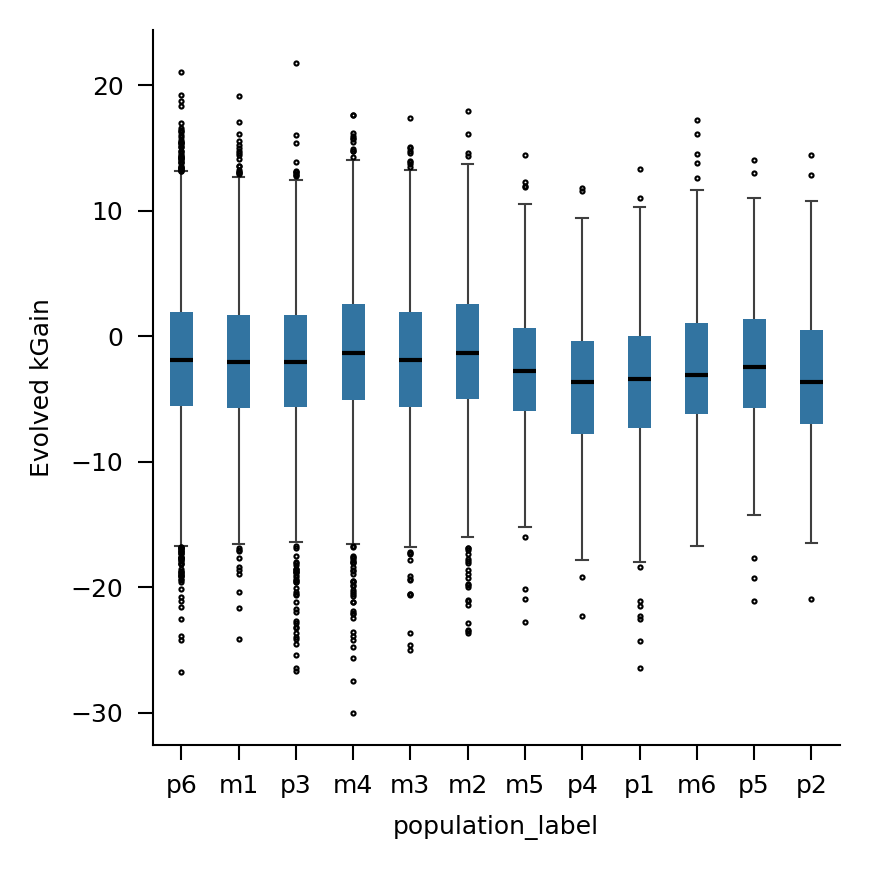

In [46]:
fig, ax = plt.subplots(1, 1, figsize=(3, 3), dpi=300)
# annotated_mutations_df
ax= sns.boxplot(data=annotated_mutations_df.sort_values(["mutator_type"]),
                y = "evolved_kGain", x = "population_label",  boxprops=dict(edgecolor="black", linewidth=0),ax=ax,flierprops=dict(marker='o', markeredgecolor='black', markersize=0.5), width=0.4,linewidth=0.5, fliersize=0.15, dodge=True, medianprops={"color": "black","linewidth":1})
ax= utility.custom_figure_axis(ax, fontsize=6, show_ticks = True, rotation=0)
ax.set_ylabel("Evolved kGain")
plt.tight_layout()
# plt.savefig("Evolved kGain vs population.pdf", dpi =300)


In [47]:
from scipy.stats import mannwhitneyu

mutator_vals = annotated_mutations_df.loc[
    annotated_mutations_df['mutator_type'] == 'mutator', 'evolved_kGain'
].dropna()
non_mutator_vals = annotated_mutations_df.loc[
    annotated_mutations_df['mutator_type'] == 'non_mutator', 'evolved_kGain'
].dropna()

u_stat, p_raw = mannwhitneyu(mutator_vals, non_mutator_vals, alternative='greater')
d_value, ci_low, ci_high = utility.median_based_distance_ci(mutator_vals, non_mutator_vals)

panel_f_stats_df = pd.DataFrame([
    {
        'panel': 'Fig1gi',
        'comparison': 'mutator vs non_mutator',
        'test': 'Mann-Whitney U',
        'alternative': 'greater',
        'n_group1': int(mutator_vals.shape[0]),
        'n_group2': int(non_mutator_vals.shape[0]),
        'u_stat': float(u_stat),
        'effect_size_d': float(d_value),
        'ci_low': float(ci_low),
        'ci_high': float(ci_high),
        'p_raw': float(p_raw),
        'p_adj': float(p_raw),
        'p_adjust_method': 'none_single_test',
    }
])

row = panel_f_stats_df.iloc[0]
print(
    f"Fig1gi | raw_p={row['p_raw']:.2e}, p_adj={row['p_adj']:.2e}, "
    f"d={row['effect_size_d']:.2e}, 95% CI [{row['ci_low']:.2e}, {row['ci_high']:.2e}]"
)
panel_f_stats_df


Fig1gi | raw_p=5.42e-39, p_adj=5.42e-39, d=3.74e-01, 95% CI [3.07e-01, 4.28e-01]


,panel,comparison,test,alternative,n_group1,n_group2,u_stat,effect_size_d,ci_low,ci_high,p_raw,p_adj,p_adjust_method
0,Fig1gi,mutator vs non_mutator,Mann-Whitney U,greater,33784,3138,60437146.5,0.373681,0.307315,0.427986,5.420875e-39,5.420875e-39,none_single_test


##### Fig 1i

In [48]:
mutation_with_essentiality_df_mutator = mutation_with_essentiality_df[
    mutation_with_essentiality_df["mutator_type"] == "mutator"
].copy()
mutation_with_essentiality_df_mutator["citrus_utilization_gen"] = np.where(
    mutation_with_essentiality_df_mutator['generation_number'] <= 33000,
    "<=33000",
    '>33000'
)


Label=p3, p_raw=4.39e-129, p_reported=1.32e-128, effect size=1.57e-01, 95% CI [1.38e-01, 1.75e-01]
Label=p6, p_raw=2.16e-201, p_reported=1.30e-200, effect size=1.73e-01, 95% CI [1.58e-01, 1.82e-01]
Label=m1, p_raw=2.25e-68, p_reported=2.70e-68, effect size=2.14e-01, 95% CI [1.83e-01, 2.29e-01]
Label=m2, p_raw=1.79e-124, p_reported=3.57e-124, effect size=2.37e-01, 95% CI [2.18e-01, 2.59e-01]
Label=m3, p_raw=5.48e-100, p_reported=8.22e-100, effect size=3.95e-01, 95% CI [3.60e-01, 4.52e-01]
Label=m4, p_raw=2.34e-50, p_reported=2.34e-50, effect size=1.47e-01, 95% CI [1.28e-01, 1.65e-01]
Saved stats summary: fig1gi_stats_summary.csv


,category,x_column,y_column,hue_column,group1_name,group2_name,n_group1,n_group2,test,alternative,effect_size_name,effect_size,ci_level,ci_low,ci_high,p_raw,p_adjust_method,p_adjusted,panel
0,p3,population_label,evolved_kGain,citrus_utilization_gen,>33000,<=33000,85565,67245,Mann-Whitney U,greater,median_based_distance,0.157096,95,0.138204,0.175111,4.393292e-129,fdr_bh,1.317988e-128,Fig1gi
1,p6,population_label,evolved_kGain,citrus_utilization_gen,>33000,<=33000,212483,161130,Mann-Whitney U,greater,median_based_distance,0.172928,95,0.157538,0.181872,2.164574e-201,fdr_bh,1.298744e-200,Fig1gi
2,m1,population_label,evolved_kGain,citrus_utilization_gen,>33000,<=33000,86571,19825,Mann-Whitney U,greater,median_based_distance,0.214133,95,0.182619,0.228924,2.252809e-68,fdr_bh,2.703371e-68,Fig1gi
3,m2,population_label,evolved_kGain,citrus_utilization_gen,>33000,<=33000,73030,71787,Mann-Whitney U,greater,median_based_distance,0.236688,95,0.218210,0.258918,1.786721e-124,fdr_bh,3.573441e-124,Fig1gi
4,m3,population_label,evolved_kGain,citrus_utilization_gen,>33000,<=33000,40042,8671,Mann-Whitney U,greater,median_based_distance,0.395481,95,0.359596,0.452126,5.479758e-100,fdr_bh,8.219637e-100,Fig1gi
5,m4,population_label,evolved_kGain,citrus_utilization_gen,>33000,<=33000,77621,46288,Mann-Whitney U,greater,median_based_distance,0.147451,95,0.128202,0.164704,2.341829e-50,fdr_bh,2.341829e-50,Fig1gi


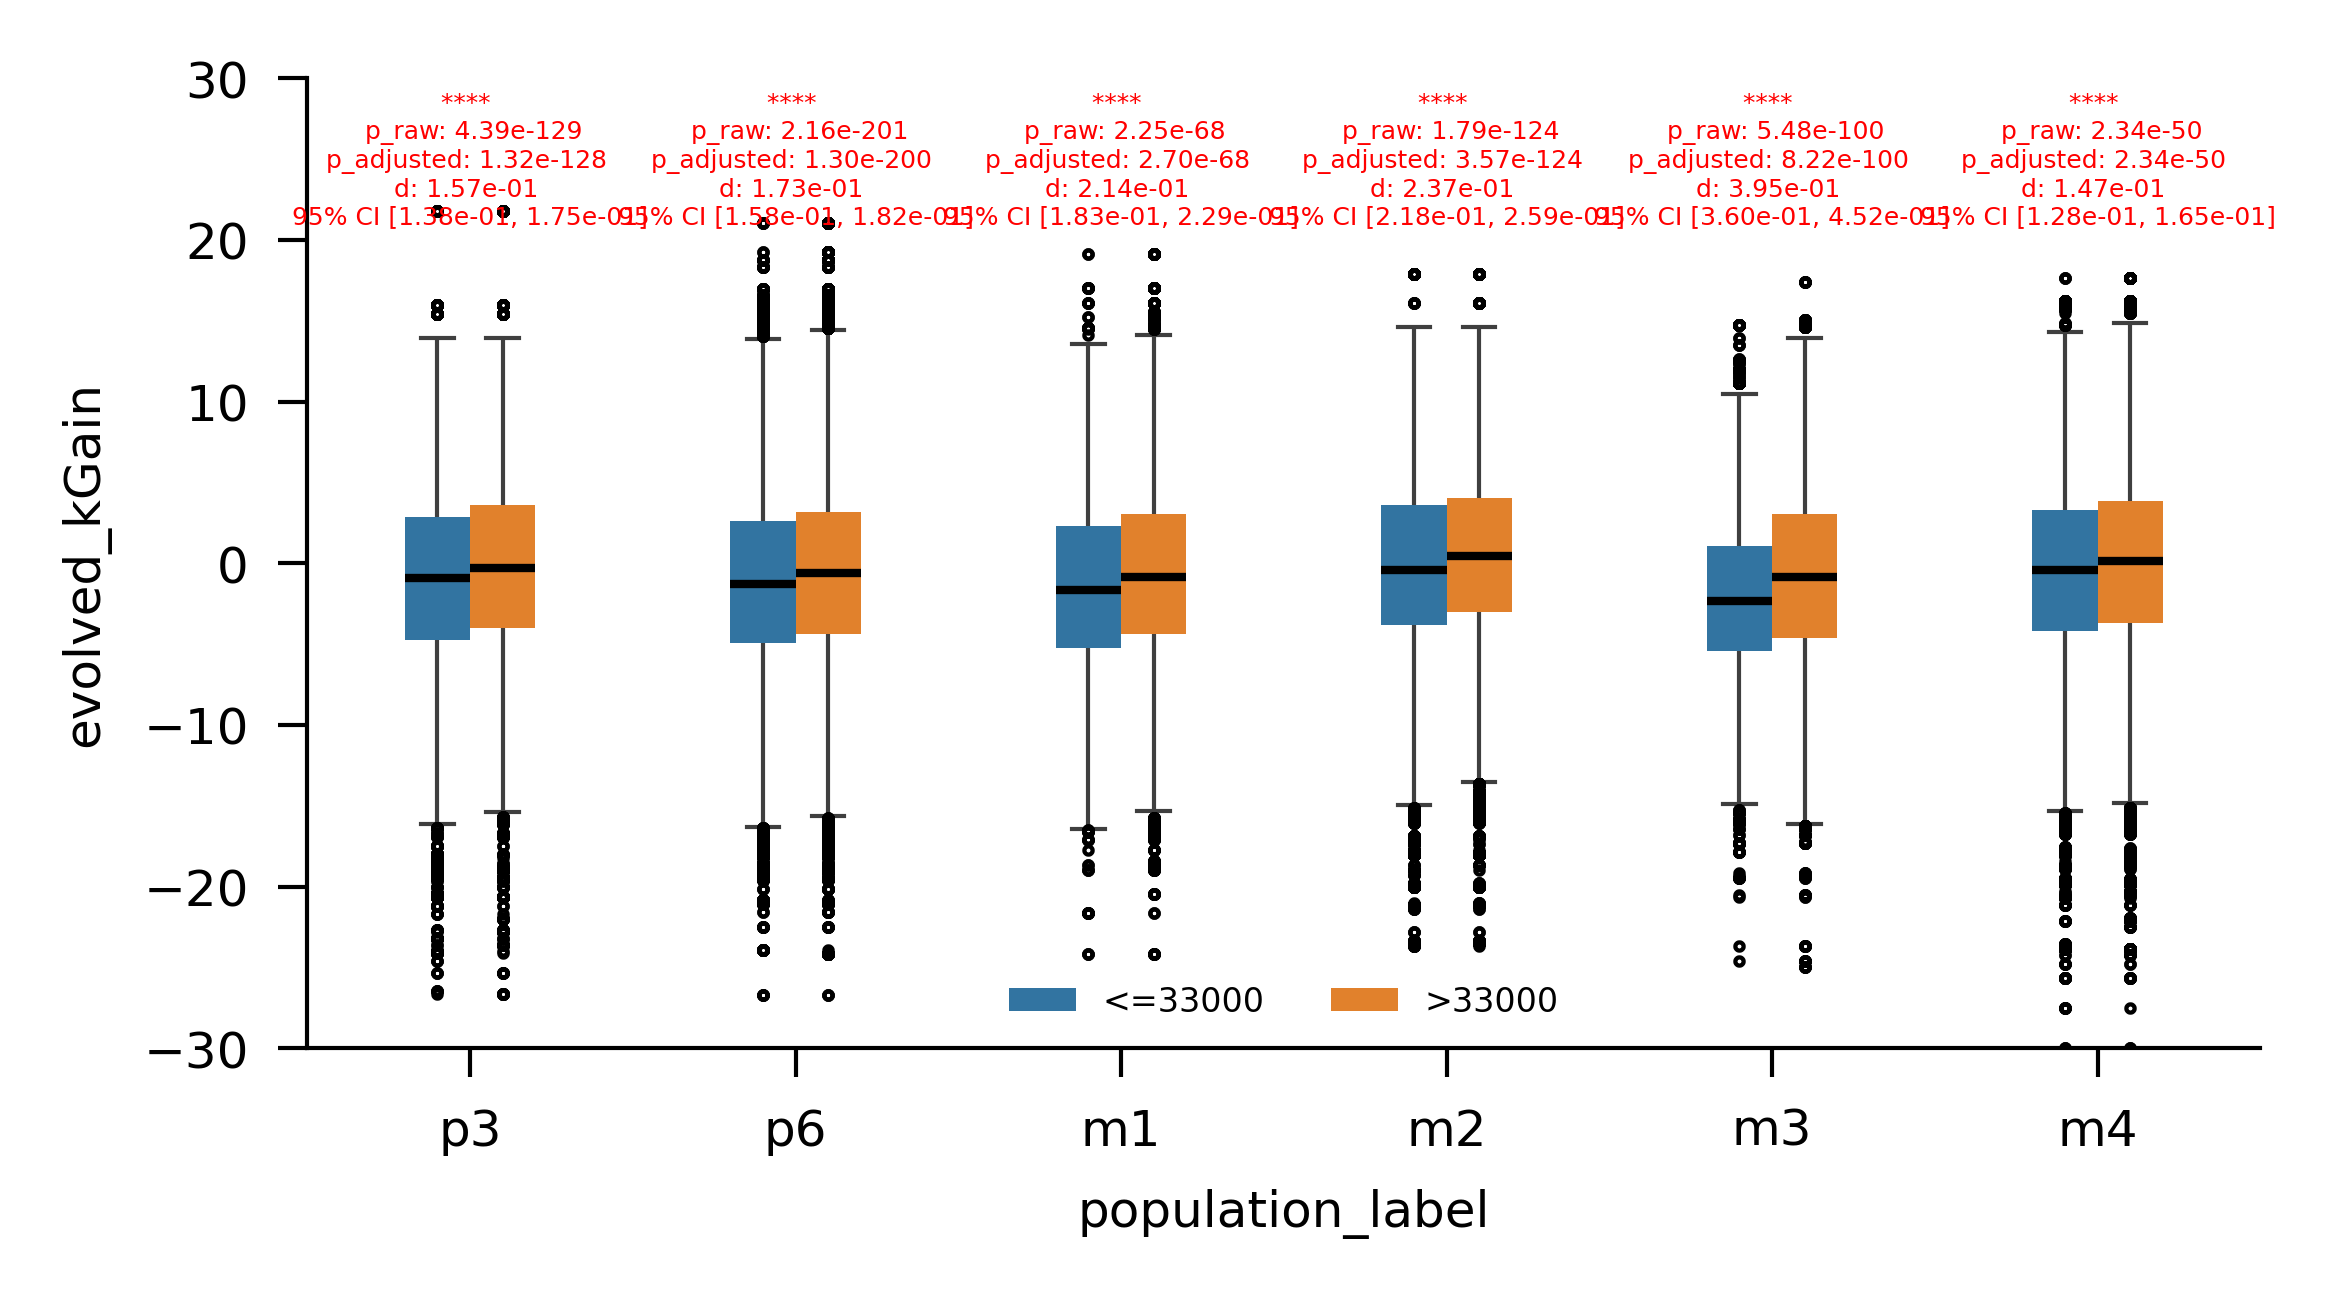

In [49]:
# sns.reset_defaults()
fig, ax = plt.subplots(1, 1, dpi=600, figsize=(4.2, 2.1), sharex=True)

ax = sns.boxplot(
    data=mutation_with_essentiality_df_mutator,
    y='evolved_kGain',
    x='population_label',
    hue='citrus_utilization_gen',
    boxprops=dict(edgecolor='black', linewidth=0),
    ax=ax,
    flierprops=dict(marker='o', markeredgecolor='black', markersize=0.5),
    width=0.4,
    linewidth=0.5,
    fliersize=0.15,
    dodge=True,
    medianprops={'color': 'black', 'linewidth': 1}
)
ax = utility.custom_figure_axis(ax, fontsize=6, show_ticks=True, rotation=0)
ax.legend(ncol=2, fontsize=4, frameon=False)

ax = utility.return_box_with_p_effect_size(
    ax=ax,
    data=mutation_with_essentiality_df_mutator,
    x_columns='population_label',
    y_columns='evolved_kGain',
    group1_name='>33000',
    group2_name='<=33000',
    y_pos=21,
    hue_columns='citrus_utilization_gen',
    fontsize=3,
    p_adjust_method='fdr_bh',
    alternative='greater'
)

panel_g_stats_df = utility.summarize_boxplot_pairwise_stats(
    data=mutation_with_essentiality_df_mutator,
    x_columns='population_label',
    y_columns='evolved_kGain',
    group1_name='>33000',
    group2_name='<=33000',
    hue_columns='citrus_utilization_gen',
    p_adjust_method='fdr_bh',
    alternative='greater'
)
panel_g_stats_df['panel'] = 'Fig1gi'

ax.set_ylim(-30, 30)

if 'panel_f_stats_df' in globals():
    stats_summary_df = pd.concat([panel_f_stats_df, panel_g_stats_df], ignore_index=True, sort=False)
else:
    stats_summary_df = panel_g_stats_df.copy()

stats_out = 'fig1gi_stats_summary.csv'
stats_summary_df.to_csv(stats_out, index=False)
print(f'Saved stats summary: {stats_out}')

panel_g_stats_df
